# synthetic_control Exploration
## Introduction



In [1]:
%reset -f

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
from scipy.optimize import minimize

pd.options.display.float_format = '{:20,.2f}'.format

In [3]:
co2 = pd.read_stata("/home/michael/Projects/essays/swedish_cp_replication/carbontax_fullsample_data.dta")

co2 = co2[(co2['country'].isin(["Sweden",
                  "Australia",
                  "Belgium",
                  "Canada",
                  "Denmark",
                  "France",
                  "Greece",
                  "Iceland",
                  "Japan",
                  "New Zealand",
                  "Poland",
                  "Portugal",
                  "Spain",
                  "Switzerland",
                  "United States"])) & 
                   (co2['year'] > 1959) &
                   (co2['year'] < 2006)]


covariates = ['GDP_per_capita', 
              'gas_cons_capita', 
              'vehicles_capita', 
              'urban_pop']

outcome_var = 'CO2_transport_capita'
treatment_period = 1990
time_var = "year"
id_var = "Countryno"
treated_unit = 21

periods_all = co2[time_var].nunique()
periods_pre_treatment = co2.loc[co2[time_var]<treatment_period][time_var].nunique()
n_controls = co2[id_var].nunique() - 1
control_units = co2.loc[co2[id_var] != treated_unit][id_var].unique()

# treated transforms
treated_data_all = co2.loc[co2[id_var] == treated_unit]
treated_outcome_all = np.array(treated_data_all[outcome_var]).reshape(periods_all,1) #All outcomes

##Only pre-treatment
treated_data = treated_data_all.loc[co2[time_var] < treatment_period]
#Extract outcome and shape as matrix
treated_outcome = np.array(treated_data[outcome_var]).reshape(periods_pre_treatment, 1)

X_1 = co2[(co2['year'] >= 1980) & (co2['year'] < 1990) & 
         (co2['country'] == "Sweden")].groupby(['Countryno'])[covariates].mean()


X_1 = pd.merge(X_1,
         co2[co2['year'] == 1989].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1989"})

X_1 = pd.merge(X_1,
         co2[co2['year'] == 1980].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1980"})

X_1 = pd.merge(X_1,
         co2[co2['year'] == 1970].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1970"}).drop(columns = ['Countryno']).T


#Every unit that is not the treated unit is control
control_data_all = co2.loc[co2[id_var] != treated_unit]
control_outcome_all = np.array(control_data_all[outcome_var]).reshape(n_controls, periods_all).T 
        
#Only pre-treatment
control_data = control_data_all.loc[co2[time_var] < treatment_period]
#Extract outcome, then shape as matrix
control_outcome = np.array(control_data[outcome_var]).reshape(n_controls, periods_pre_treatment).T
        
X_0 = co2[(co2['year'] >= 1980) & (co2['year'] < 1990) & 
         (co2['country'] != "Sweden")].groupby(['Countryno'])[covariates].mean()


X_0 = pd.merge(X_0,
         co2[co2['year'] == 1989].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1989"})

X_0 = pd.merge(X_0,
         co2[co2['year'] == 1980].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1980"})

X_0 = pd.merge(X_0,
         co2[co2['year'] == 1970].groupby("Countryno")['CO2_transport_capita'].mean().reset_index(),
        how = "left",
        on = 'Countryno').rename(columns = {"CO2_transport_capita" : "CO2_transport_capita_1970"}).drop(columns = ['Countryno']).T

# load in other data
treated_covariates = np.asarray(X_1)
control_covariates = np.asarray(X_0)

n_covariates = len(control_covariates)

## scaled covariariates by varaince
df = np.column_stack((X_0, X_1))

divisor = np.sqrt(df.var(axis=1, ddof=1))

scaled_matrix = df * (1.0 / divisor)[:, np.newaxis]

del df

control_covariates = scaled_matrix[:, :n_controls]
treated_covariates = scaled_matrix[:, -1]

# resahpe treated covs - if you don't reshape the array it wigs out the optimsation problem (this took me ages to figure out)
treated_covariates = treated_covariates.reshape(-1, 1)

# optimisation problem
args = (treated_outcome, treated_covariates, # Z_1, X_1
        control_outcome, control_covariates) # Z_0, X_0

# assume initial starting v of uniform weights
v_0 = np.full(n_covariates, 1/n_covariates)

# set bounds based on covariates
bnds = tuple((0,1) for _ in range(n_covariates))

#total_looss func
def total_loss(v_0, 
               treated_outcome, 
               treated_covariates,
               control_outcome, 
               control_covariates):
    
    n_controls = control_outcome.shape[1]
    
    v_0 = np.abs(v_0) / np.sum(np.abs(v_0))
    V = np.diag(v_0)

    w = cp.Variable((n_controls, 1), nonneg=True)
    
    treated_synth_difference = cp.sum(V @ cp.square(treated_covariates - control_covariates @ w))
    
    objective = cp.Minimize(treated_synth_difference)
    
    constraints = [cp.sum(w) == 1, w >= 0, w <= 1]
    
    problem = cp.Problem(objective, constraints)
    
    result = problem.solve(verbose=False)
    loss = (treated_outcome - control_outcome @ w.value).T @ (treated_outcome - control_outcome @ w.value)
    loss = loss / len(control_outcome)

    return loss

# optimise the nested function
res = minimize(total_loss, 
               v_0,  
               args=(args),
               method='Nelder-Mead',
               #method='BFGS',
               bounds=bnds)

V_Star = abs(res.x) /  sum(abs(res.x))

np.round(V_Star,4)

array([0.0947, 0.0188, 0.0714, 0.2495, 0.1104, 0.3879, 0.0673])

In [4]:
n_controls = control_outcome.shape[1]

# Construct the problem - constrain weights to be non-negative
w = cp.Variable((n_controls, 1), nonneg=True)
    
treated_synth_difference = cp.sum(V_Star @ cp.square(treated_covariates - control_covariates @ w))
    
objective = cp.Minimize(treated_synth_difference)
    
constraints = [cp.sum(w) == 1] # non negative weights assigned above in w
    
problem = cp.Problem(objective, constraints)
    
result = problem.solve(verbose=False)
loss = (treated_outcome - control_outcome @ w.value).T @ (treated_outcome - control_outcome @ w.value)
    
np.round(w.value,4)

array([[0.    ],
       [0.1965],
       [0.    ],
       [0.3802],
       [0.    ],
       [0.0903],
       [0.    ],
       [0.    ],
       [0.1812],
       [0.    ],
       [0.    ],
       [0.    ],
       [0.0642],
       [0.0876]])

Potential explanation for the slightly different $V^*$ but approximately identical $W^*$ [here](https://mpra.ub.uni-muenchen.de/106390/14/MPRA_paper_106390.pdf).

<Axes: xlabel='year', ylabel='value'>

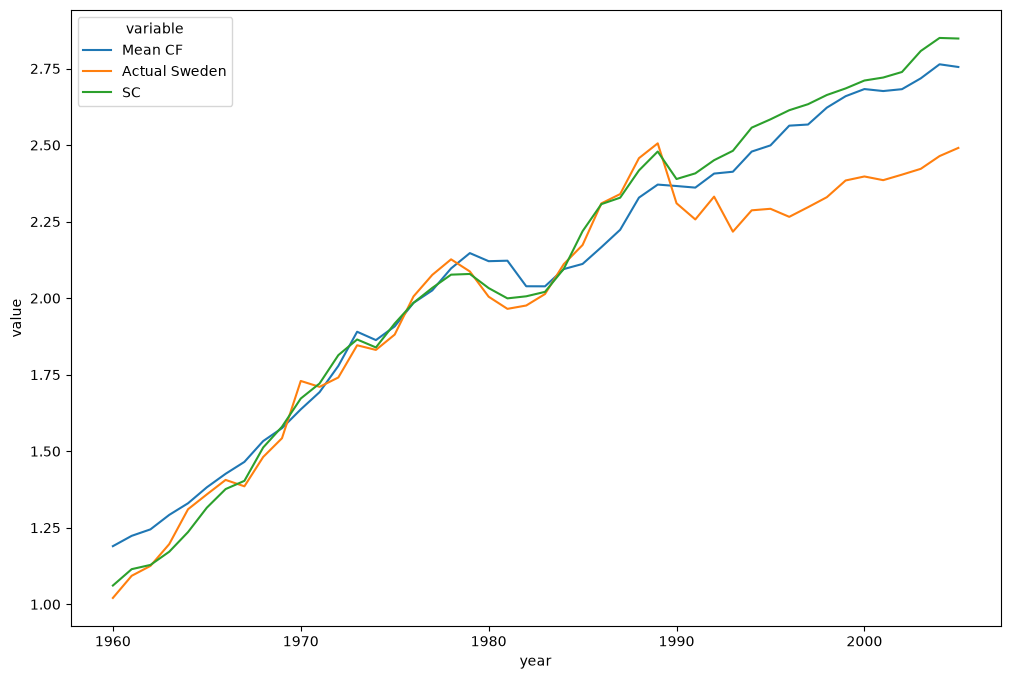

In [5]:
plot_df = pd.melt(pd.merge(pd.merge(co2[(co2['year'] >= 1960) &
          (co2['country'] != "Sweden")].pivot(index = "Countryno", 
                                              columns = 'year', 
                                              values = "CO2_transport_capita").mean().reset_index().rename(columns = {0 : "Mean CF"}),
         co2[(co2['year'] >= 1960) &
             (co2['country'] == "Sweden")].pivot(index = "Countryno", 
                                             columns = 'year', 
                                             values = "CO2_transport_capita").mean().reset_index().rename(columns = {0 : "Actual Sweden"}),
        how = "left",
        on = "year"),
         co2[(co2['year'] >= 1960) &
         (co2['country'] != "Sweden")].pivot(index = "year", 
                                             columns = 'Countryno', 
                                             values = "CO2_transport_capita").dot(w.value).reset_index().rename(columns = {0 : "SC"}),

        how = "left",
        on = "year"),
       id_vars=["year"])

plt.figure(figsize = (12,8))
sns.lineplot(data = plot_df, x = "year", y = "value", hue = "variable")